**Bitcoin Market Sentiment vs Trader Performance Analysis**

Problem Statement :-

This project analyzes how market sentiment (fear vs Greed ) impacts the trader behavior and performance.

By combining sentiment data with historical trading data,we aim  to understand the pattern in profitability and risk- taking in trading activity to derive actional trading insights.

## Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Uploading and Loading the Datasets

In [2]:
sentiment = pd.read_csv("fear_greed_index.csv")  #replace the file path with yours file path
trades = pd.read_csv("historical_data.csv")  #replace the file path with yours file path

print("Sentiment Data :-")
print(sentiment.head())

print("\nTrading Data:-")
print(trades.head())

Sentiment Data :-
    timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03
3  1517722200     24   Extreme Fear  2018-02-04
4  1517808600     11   Extreme Fear  2018-02-05

Trading Data:-
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09

/tmp/ipykernel_1311/1007852568.py:2: DtypeWarning: Columns (12) have mixed types. Specify dtype option on import or set low_memory=False.
  trades = pd.read_csv("/content/historical_data.csv")


# Data understanding

In [3]:
print("Sentiment Data Info:-")
print(sentiment.info())
print("\nTrading Data Info:-")
print(trades.info())

Sentiment Data Info:-
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB
None

Trading Data Info:-
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149258 entries, 0 to 149257
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           149258 non-null  object 
 1   Coin              149258 non-null  object 
 2   Execution Price   149258 non-null  float64
 3   Size Tokens       149258 non-null  float64
 4   Size USD          149258 non-null  float64
 5   Side              149258 non-null  object 
 6   Timestamp IST     149258 non-nu

*Form above we, understant that there is no null  null value in sentiment and there is only one column having null value in trades*

*There are columns with date and time involving in both sentiment and trades so, we have to work on them*

# Data Cleaning


In [4]:
# Convert to datetime FIRST
sentiment["date"] = pd.to_datetime(sentiment["date"])
trades["time"] = pd.to_datetime(trades["Timestamp IST"], dayfirst=True)

# Extract date
sentiment["Date"] = sentiment["date"].dt.date
trades["Date"] = trades["time"].dt.date

# Handling Missing Values

In [5]:
print("Sentiment Data Missing Value info:-")
print(sentiment.isnull().sum())
print("\nTrading Data Missing Value info:-")
print(trades.isnull().sum())

trades = trades.dropna()
sentiment = sentiment.dropna()


Sentiment Data Missing Value info:-
timestamp         0
value             0
classification    0
date              0
Date              0
dtype: int64

Trading Data Missing Value info:-
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           1
Closed PnL          1
Transaction Hash    1
Order ID            1
Crossed             1
Fee                 1
Trade ID            1
Timestamp           1
time                0
Date                0
dtype: int64


# Feature Engineering

In [6]:
# Createing Profit Indicator
trades["is_profit"] = trades["Closed PnL"] > 0

daily_trades = trades.groupby("Date").agg({
    'Closed PnL':'sum',
    'Size Tokens':'sum',
    'is_profit':'mean'
}).reset_index()

daily_trades.rename(columns={
    'Closed PnL':"daily_pnl",
    'Size Tokens':'volume',
    'is_profit':'win_rate'
    },inplace=True)


daily_trades.head()

,Date,daily_pnl,volume,win_rate
0,2023-05-01,0.000000,0.25130,0.000000
1,2023-12-05,0.000000,11.80901,0.000000
2,2023-12-14,-205.434737,4092.28901,0.363636
3,2023-12-15,-24.632034,3558.00000,0.000000
4,2023-12-16,0.000000,39897.00000,0.000000


# Merge Datesets

In [7]:
df = pd.merge(daily_trades,sentiment,on="Date")

df.head()

,Date,daily_pnl,volume,win_rate,timestamp,value,classification,date
0,2023-05-01,0.000000,0.25130,0.000000,1682919000,63,Greed,2023-05-01
1,2023-12-05,0.000000,11.80901,0.000000,1701754200,75,Extreme Greed,2023-12-05
2,2023-12-14,-205.434737,4092.28901,0.363636,1702531800,72,Greed,2023-12-14
3,2023-12-15,-24.632034,3558.00000,0.000000,1702618200,70,Greed,2023-12-15
4,2023-12-16,0.000000,39897.00000,0.000000,1702704600,67,Greed,2023-12-16


# EDA(Exploratory Data Analysis)

1.Profit vs Sentiment

In [8]:
df.groupby("classification")["daily_pnl"].mean()

,daily_pnl
classification,
Extreme Fear,34154.544543
Extreme Greed,18014.053881
Fear,30682.367197
Greed,6974.991381
Neutral,18379.910511


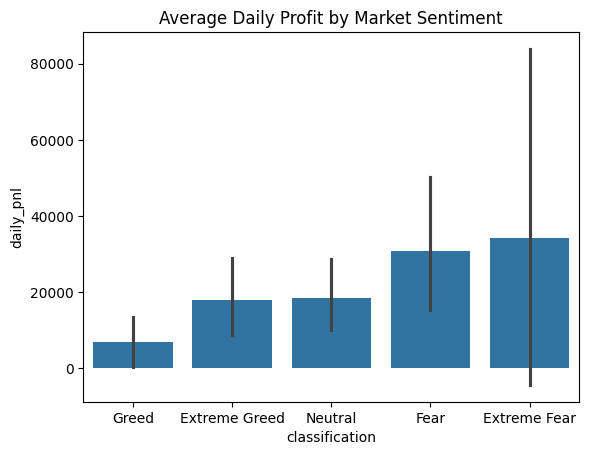

In [9]:
sns.barplot(x = 'classification', y = 'daily_pnl', data = df)
plt.title("Average Daily Profit by Market Sentiment")
plt.show()

2.Buy Sell Behavior by Sentiment

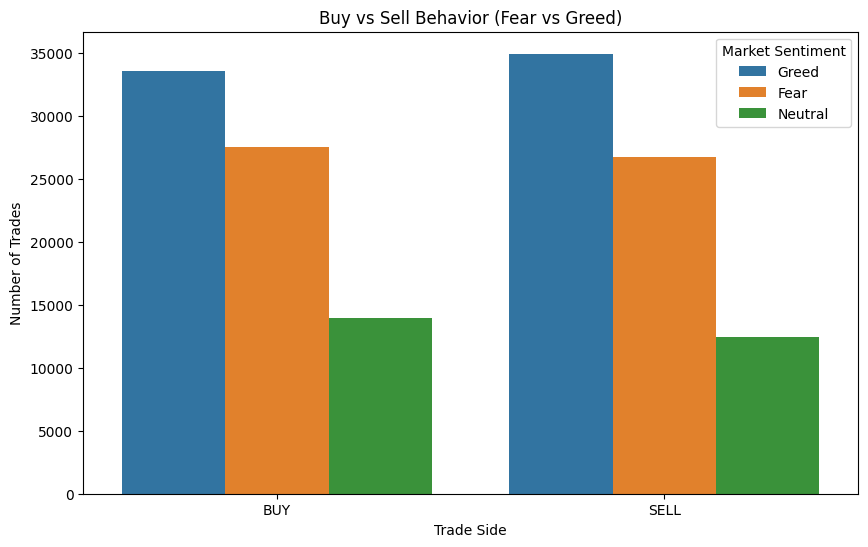


📊 Buy/Sell Percentage by Sentiment:

Sentiment_Group      Fear     Greed  Neutral
Side                                        
BUY              0.507239  0.490103  0.52726
SELL             0.492761  0.509897  0.47274


In [10]:
trades_with_sentiment = pd.merge(trades, sentiment, on='Date', how='left')

def simplify_sentiment(x):
    if "Fear" in str(x):
        return "Fear"
    elif "Greed" in str(x):
        return "Greed"
    else:
        return "Neutral"

# Create new column
trades_with_sentiment["Sentiment_Group"] = trades_with_sentiment["classification"].apply(simplify_sentiment)


plt.figure(figsize=(10,6))
sns.countplot(x='Side', hue='Sentiment_Group', data=trades_with_sentiment)

plt.title("Buy vs Sell Behavior (Fear vs Greed)")
plt.xlabel("Trade Side")
plt.ylabel("Number of Trades")
plt.legend(title="Market Sentiment")

plt.show()


behavior_percent = pd.crosstab(
    trades_with_sentiment['Side'],
    trades_with_sentiment['Sentiment_Group'],
    normalize='columns'
)

print("\n📊 Buy/Sell Percentage by Sentiment:\n")
print(behavior_percent)


3.Trading volume

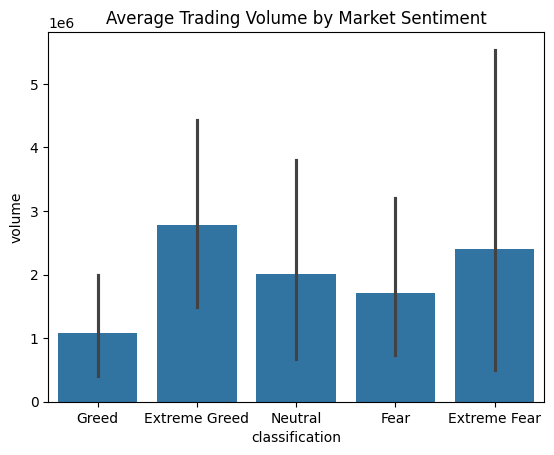

In [11]:
sns.barplot(x='classification', y='volume', data=df)
plt.title("Average Trading Volume by Market Sentiment")
plt.show()

4.Win Rate

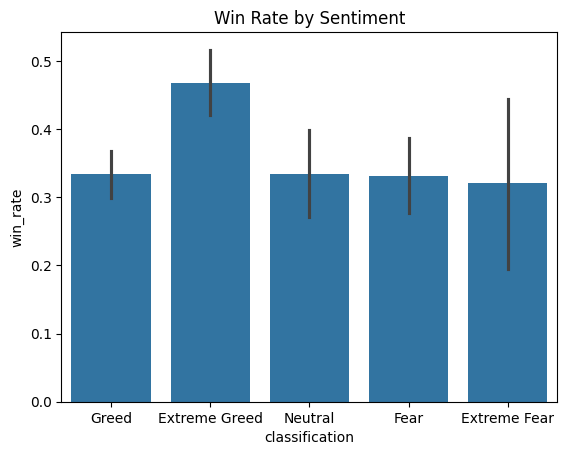

In [12]:
sns.barplot(x='classification', y='win_rate', data=df)
plt.title("Win Rate by Sentiment")
plt.show()

5.Number  of Trades

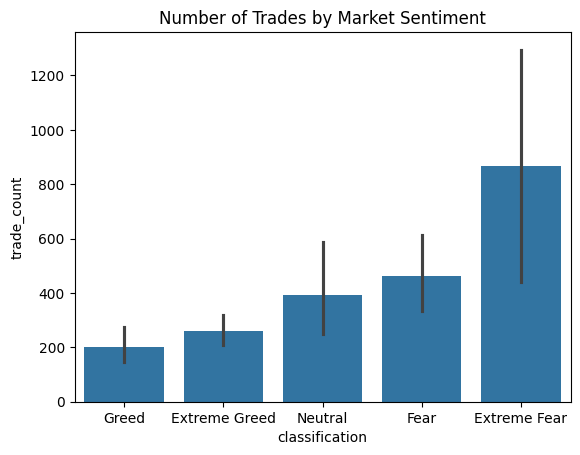

In [13]:
trades_per_day = trades.groupby("Date").size().reset_index(name="trade_count")

daily_trades = pd.merge(daily_trades, trades_per_day, on="Date", how="left")

df = pd.merge(daily_trades, sentiment, on="Date", how="left")

sns.barplot(x='classification', y='trade_count', data=df)
plt.title("Number of Trades by Market Sentiment")
plt.show()

6.Pnl Distribution

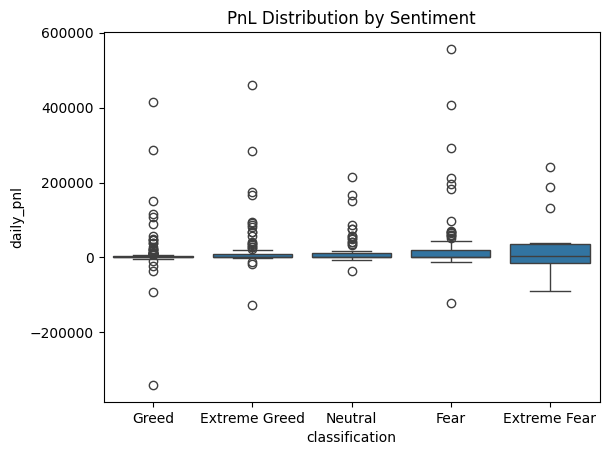

In [14]:
sns.boxplot(x='classification', y='daily_pnl', data=df)
plt.title("PnL Distribution by Sentiment")
plt.show()

10. Correlation Analysis

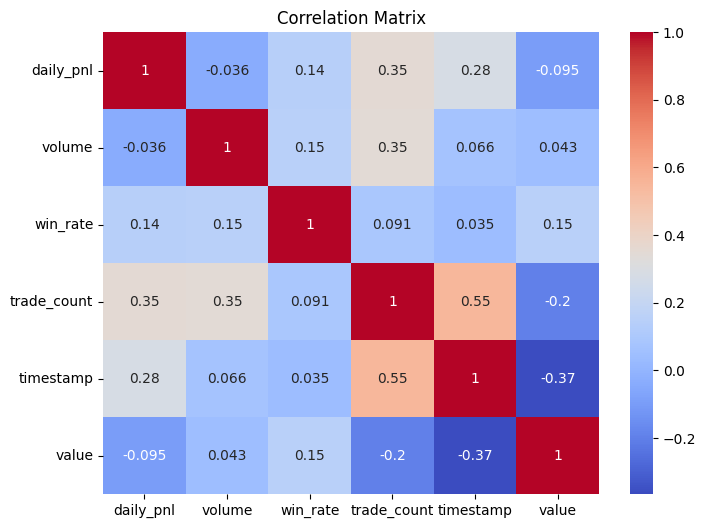

In [15]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True),annot = True ,cmap = "coolwarm")
plt.title("Correlation Matrix")
plt.show()

- Correlation analysis shows that trading volume and trade count are positively related, indicating that higher activity often accompanies increased market participation during strong sentiment phases.

# Key Insights



---


- Traders show higher trading activity during Greed phases (increased volume and trade count).
- Average profitability is higher during Fear markets (possible undervaluation).
- Trading volume increases during Greed, indicating overconfidence.
- Win rate is more stable during Fear periods.
- PnL distribution shows higher variability during Greed phases, indicating unstable and riskier trading outcomes.


---



# Final Strategy



---



- Adopt a contrarian strategy: Buy during Fear, be cautious during Greed.
- Avoid overtrading during Greed periods.
- Monitor trade size during high sentiment periods to manage risk.


---



# Conclusion



---


Market sentiment significantly influences trader behavior, with Fear phases offering better risk-adjusted opportunities, while Greed phases are associated with increased activity and potential overconfidence.


---



# Simple predictive model:

In [25]:
data = trades_with_sentiment.copy()
# Win column (target)
data['target'] = (data['Closed PnL'] > 0).astype(int)

# Trade frequency per trader
trade_counts = data.groupby('Account').size()
data['trade_count'] = data['Account'].map(trade_counts)

# Avg PnL per trader (historical behavior)
avg_pnl = data.groupby('Account')['Closed PnL'].mean()
data['avg_pnl'] = data['Account'].map(avg_pnl)

# Encode sentiment
data['classification'] = data['classification'].map({'Fear': 0, 'Greed': 1})

In [26]:
X = data[['Size USD', 'classification', 'trade_count', 'avg_pnl']]
y = data['target']

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=200, max_depth=6,random_state=42)
model.fit(X_train, y_train)

print("Accuracy:", model.score(X_test, y_test))

Accuracy: 0.6447809192013936


The predictive performance is moderate due to limited feature availability.
This indicates that trader profitability is influenced by additional factors
beyond sentiment and basic trade metrics.

However, the model still demonstrates that sentiment and trading behavior
have some predictive signal.